# SHAP and grouped permutation importance

Addresses R1.7 and figure readability. Distinguish model reliance from biological mechanism.

**Mode:** executed analysis of the committed corrected results. Expensive model refitting is available through Notebook 11 and `scripts/reproduce.py`. Replaying saved results is not presented as fresh model training.

In [1]:
from pathlib import Path
import sys, json, itertools
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.revision-repository').exists())
sys.path.insert(0, str(ROOT / 'analysis'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from notebook_support import *
from analysis import PROTEINS, TARGET, FIXED, global_quantile, local_intervals
pd.set_option('display.max_columns', 14)
pd.set_option('display.max_rows', 30)
pd.set_option('display.precision', 5)


## Grouped SHAP

The plotted group statistic is **mean(abs(sum(SHAP within group)))**. This differs from summing absolute individual importances and is not an additive percentage breakdown. Native CatBoost SHAP values include an expected-value column.

,model,group,mean_abs_grouped_shap,n_features,n_sample
0,Baseline,Fingerprints,0.21950,2048,512
1,Baseline,Proteins,0.11431,44,512
2,Baseline,PhysChem,0.17423,2,512
3,Baseline,ADME,NaN,0,512
4,PCA,Fingerprints,0.23131,2048,512
5,PCA,Proteins,0.07268,3,512
6,PCA,PhysChem,0.20211,2,512
7,PCA,ADME,NaN,0,512
8,ADME,Fingerprints,0.06880,2048,512
9,ADME,Proteins,0.03825,44,512


SHAP additivity checked for all five primary models.


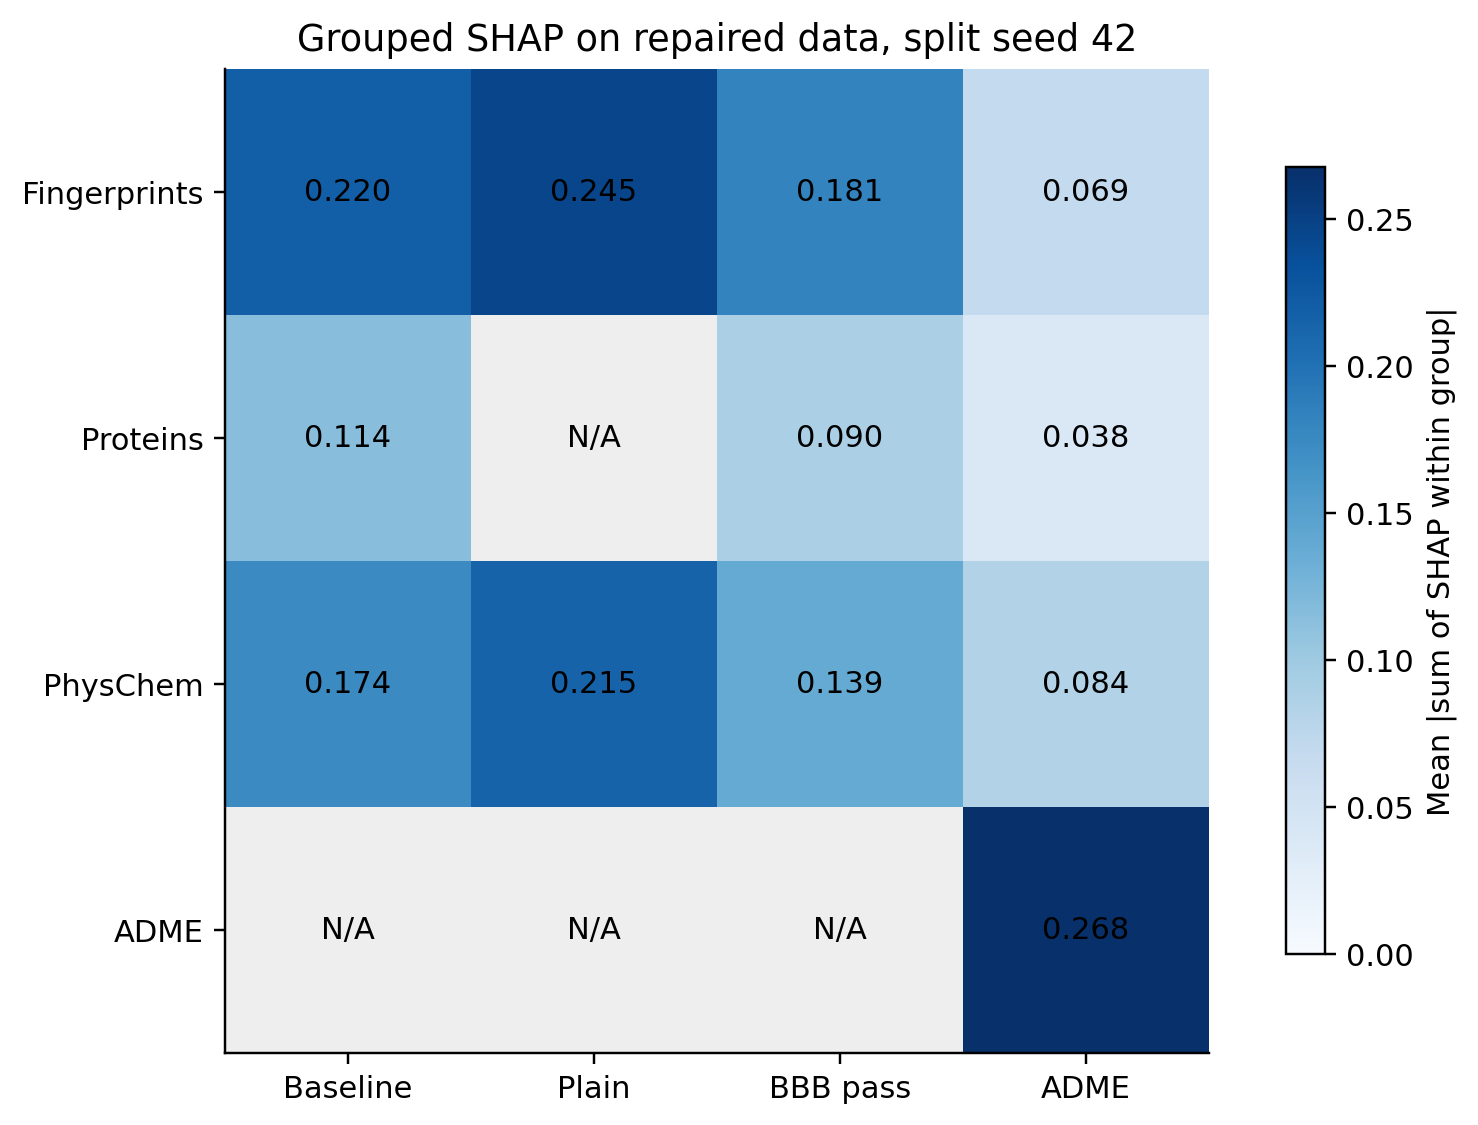

In [2]:
grouped=table('tables/figure3_grouped_shap.csv');display(grouped)
for name in ['Baseline','PCA','ADME','Plain','BBB_pass']:
    a=np.load(RESULTS/f'global_models/seed42/{name}/shap_values.npz')
    from catboost import CatBoostRegressor
    model=CatBoostRegressor();model.load_model(str(RESULTS/f'global_models/seed42/{name}/model.cbm'))
    assert np.allclose(a['shap'].sum(axis=1),model.predict(a['values'],thread_count=2),atol=1e-8)
print('SHAP additivity checked for all five primary models.')
figure('results/repaired/figures/figure3_revised.png')

## What was permuted?

For Baseline and ADME, one feature block at a time is reassigned between test molecules: 2,048 fingerprint bits, MW/logP, 44 docking scores, and (ADME model only) 68 ADME descriptors. All columns of a block move together. Labels and other blocks remain fixed. No model is retrained. Five permutations per block per partition measure the increase in MSE.

features  mean_MSE_increase  partitions
model    group                                                
ADME     ADME                68            0.31687           5
         Fingerprints      2048            0.03551           5
         PhysChem             2            0.02897           5
         Proteins            44            0.01485           5
Baseline Fingerprints      2048            0.27130           5
         PhysChem             2            0.12894           5
         Proteins            44            0.06058           5

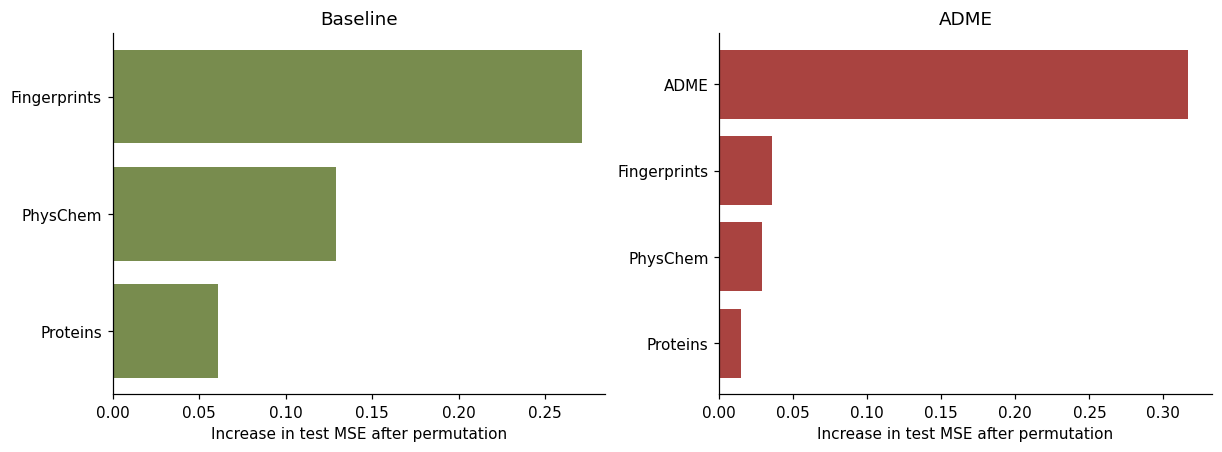

In [3]:
perm=additional('group_permutation_importance')
display(perm.groupby(['model','group']).agg(features=('n_features','first'),mean_MSE_increase=('mean_mse_increase','mean'),partitions=('seed','nunique')))
fig,axs=plt.subplots(1,2,figsize=(11,4),layout='constrained')
for ax,name in zip(axs,['Baseline','ADME']):
    g=perm[perm.model==name]
    means=g.groupby('group').mean_mse_increase.mean().sort_values()
    ax.barh(means.index,means,color=COLORS[name]);ax.set(title=name,xlabel='Increase in test MSE after permutation')
finish(fig,'group_permutation_importance')

## Re-run one full permutation block

The code below reproduces the five ADME-block permutations for seed 42, using the original permutation seed. It demonstrates the operation on the real fitted model, not on synthetic data.

In [4]:
from catboost import CatBoostRegressor
folder=RESULTS/'global_models/seed42/ADME';features=pd.read_csv(folder/'features.csv').feature.tolist()
med=pd.read_csv(folder/'imputation_medians.csv',index_col=0).iloc[:,0]
p=pd.read_csv(folder/'test_predictions.csv');x=dataset().loc[p.ligand_id,features].fillna(med)
model=CatBoostRegressor();model.load_model(str(folder/'model.cbm'))
arr=x.to_numpy();base=(p.y.to_numpy()-model.predict(arr,thread_count=2))**2
adme=set(read_json(ROOT/'data/source/admet_features.json'));cols=[i for i,c in enumerate(features) if c in adme]
rng=np.random.default_rng(20260908);deltas=[]
for repeat in range(5):
    shuffled=arr.copy()
    shuffled[:,cols]=arr[rng.permutation(len(arr))][:,cols]
    deltas.append(((p.y.to_numpy()-model.predict(shuffled,thread_count=2))**2-base).mean())
record=perm[(perm.seed==42)&(perm.model=='ADME')&(perm.group=='ADME')].iloc[0]
assert np.isclose(np.mean(deltas),record.mean_mse_increase)
print('Recomputed mean MSE increase:',np.mean(deltas))

Recomputed mean MSE increase: 0.3115971804039802


## Interpretation

The ADME model relies strongly on its ADME block. Permutation also breaks relationships between blocks and can create unusual combinations; the result is a reliance diagnostic, not a causal mechanism or proof of biological-information suppression. The same distinction applies to SHAP.

### Baseline

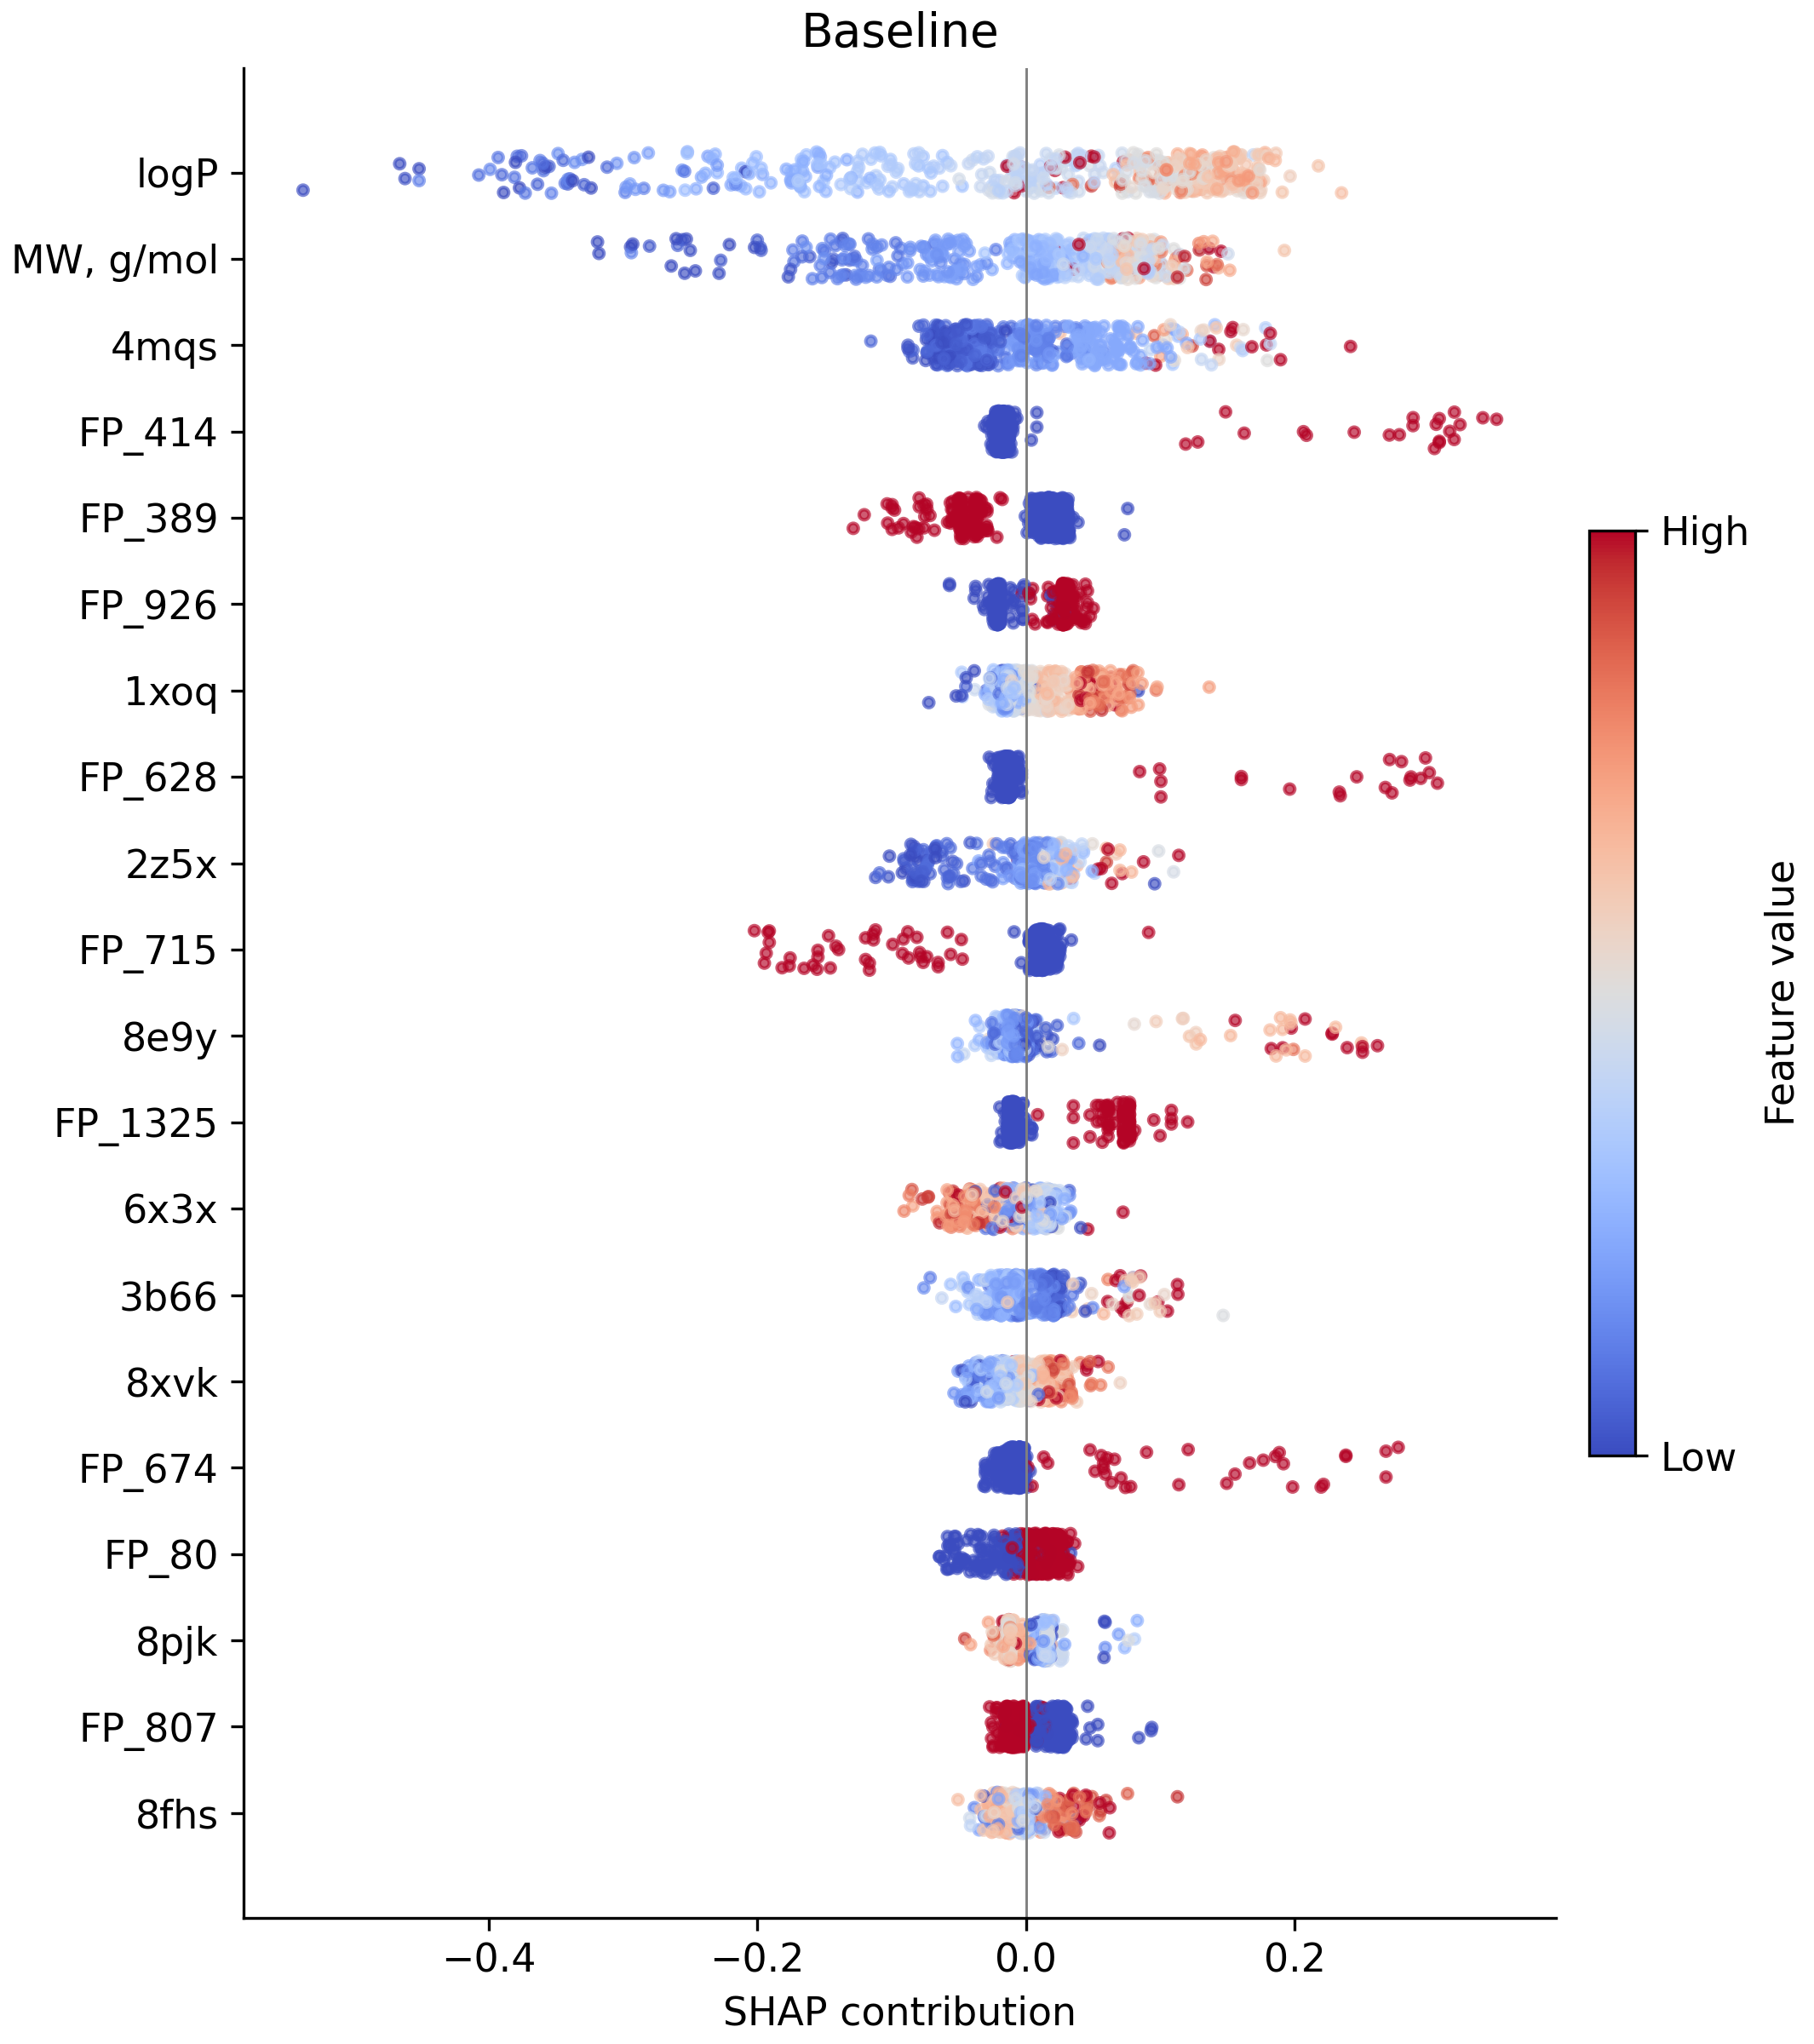

### BBB_pass

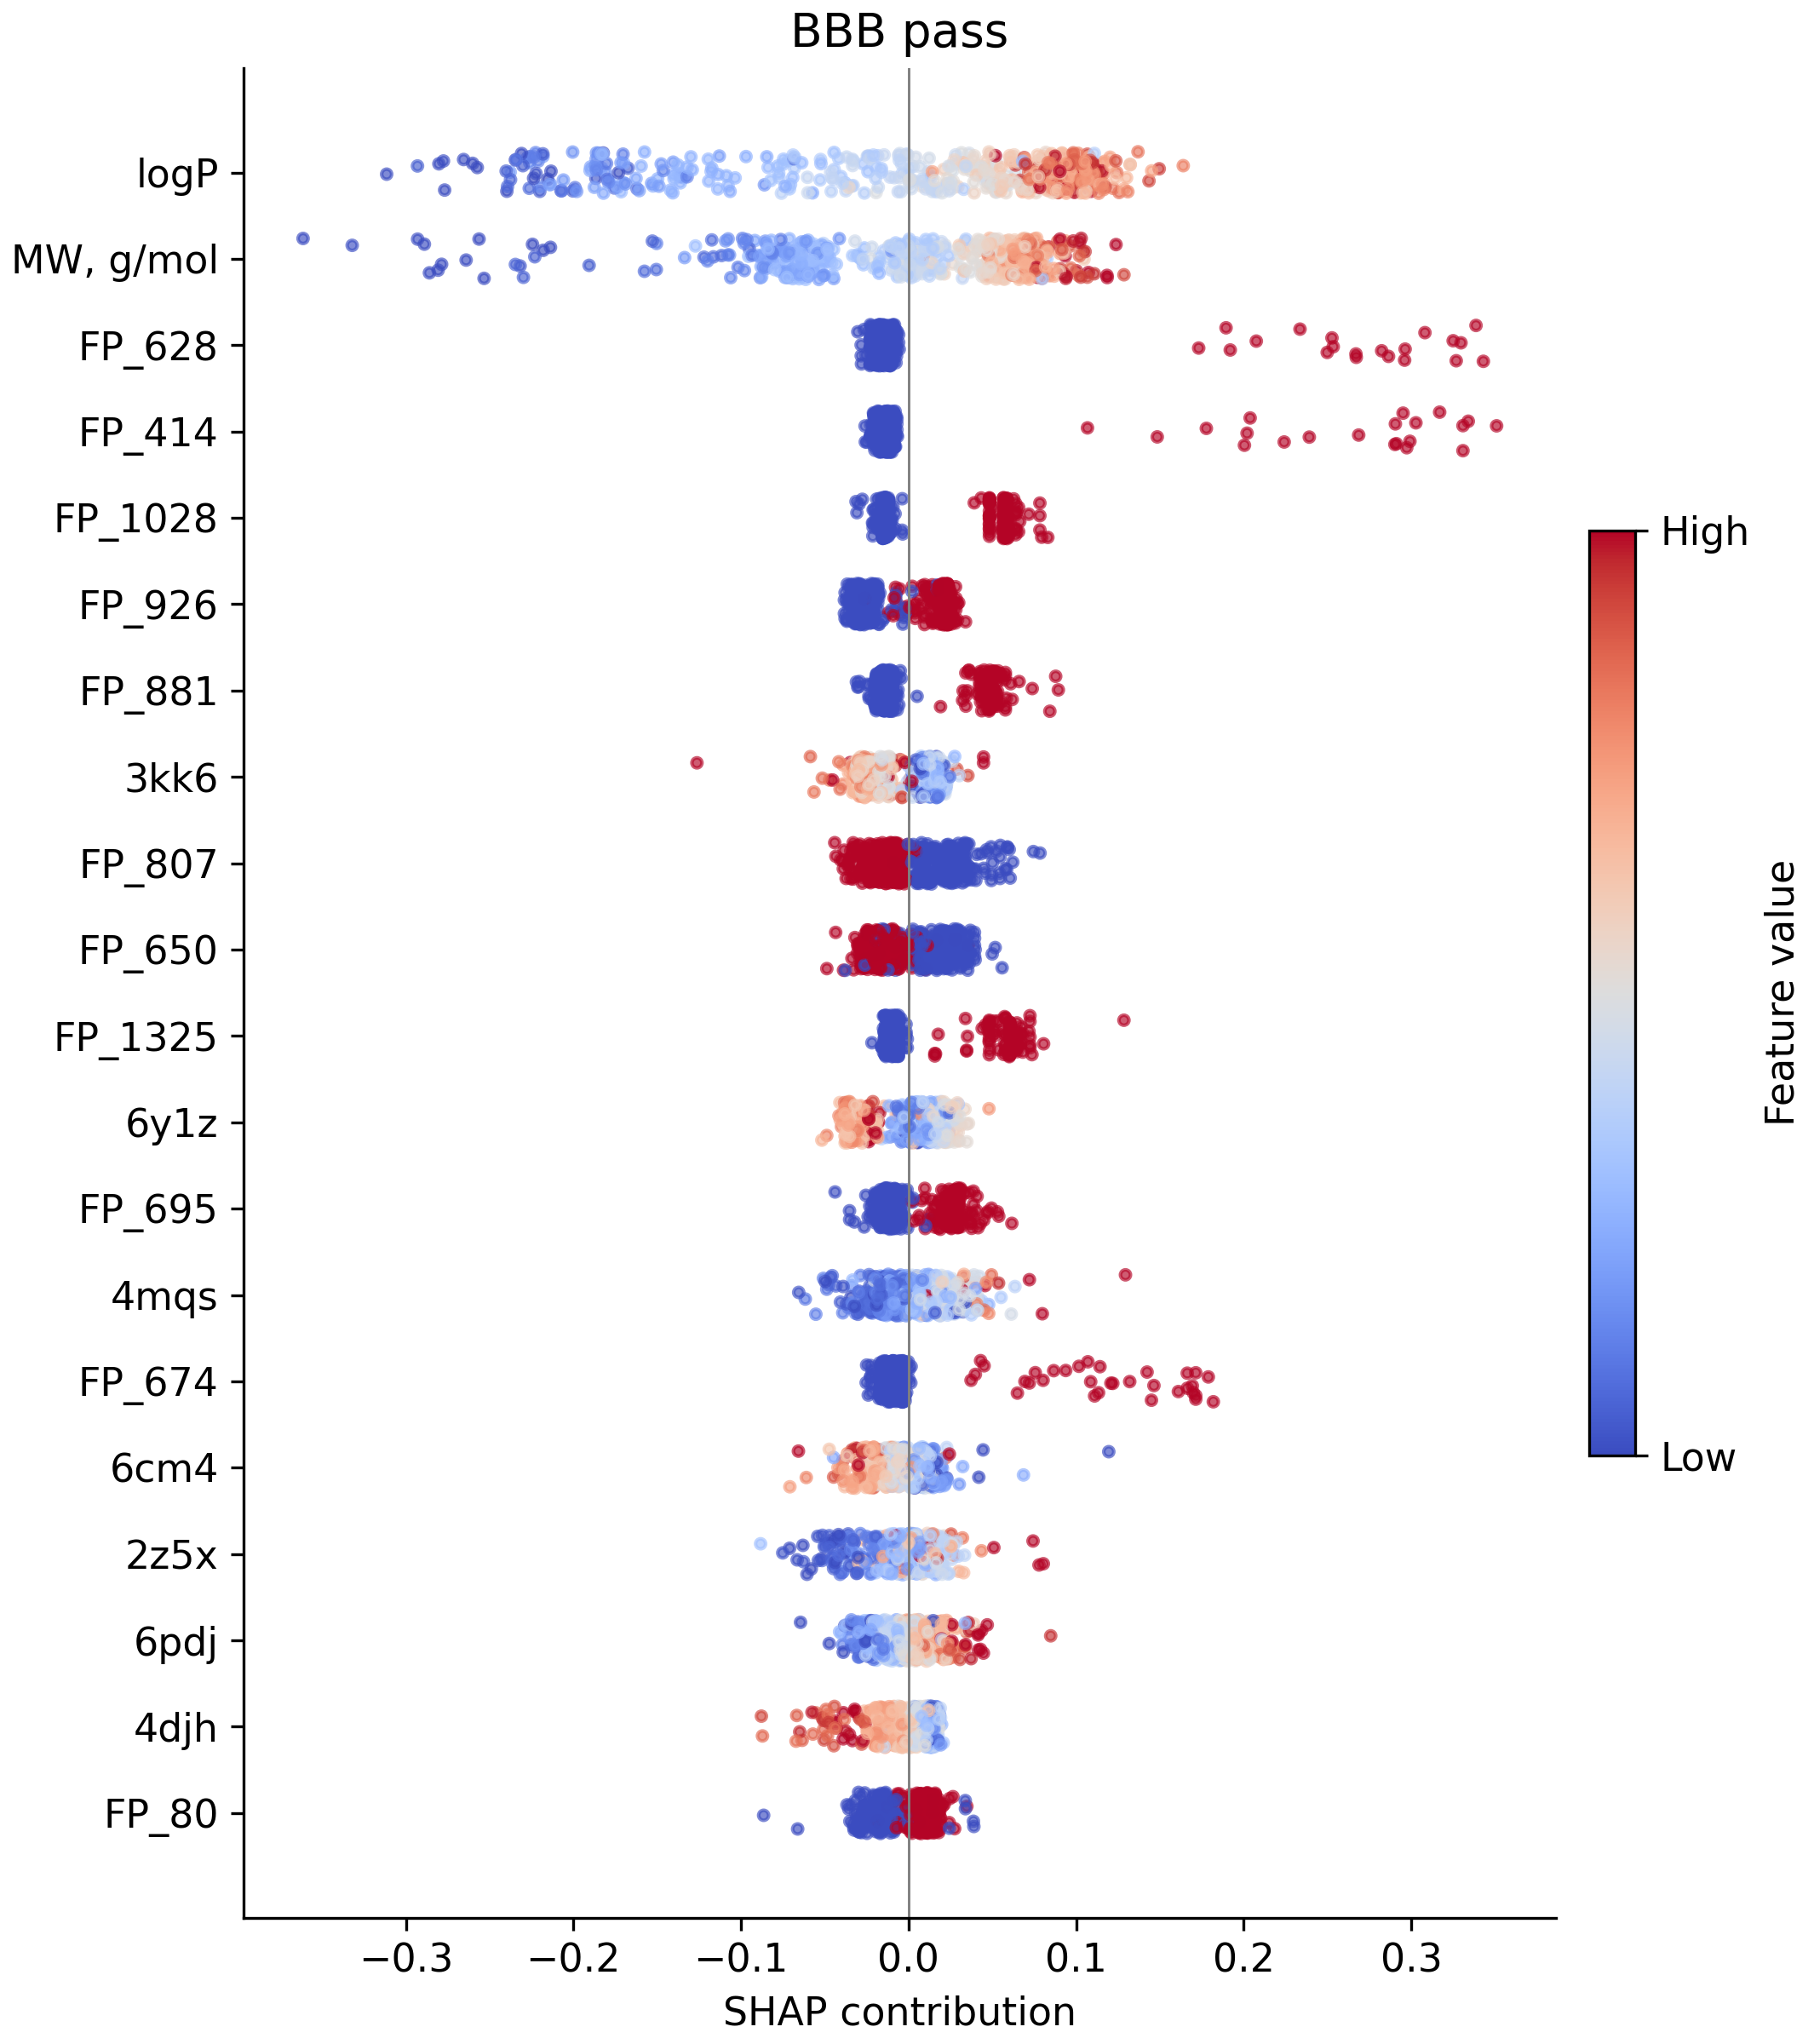

### ADME

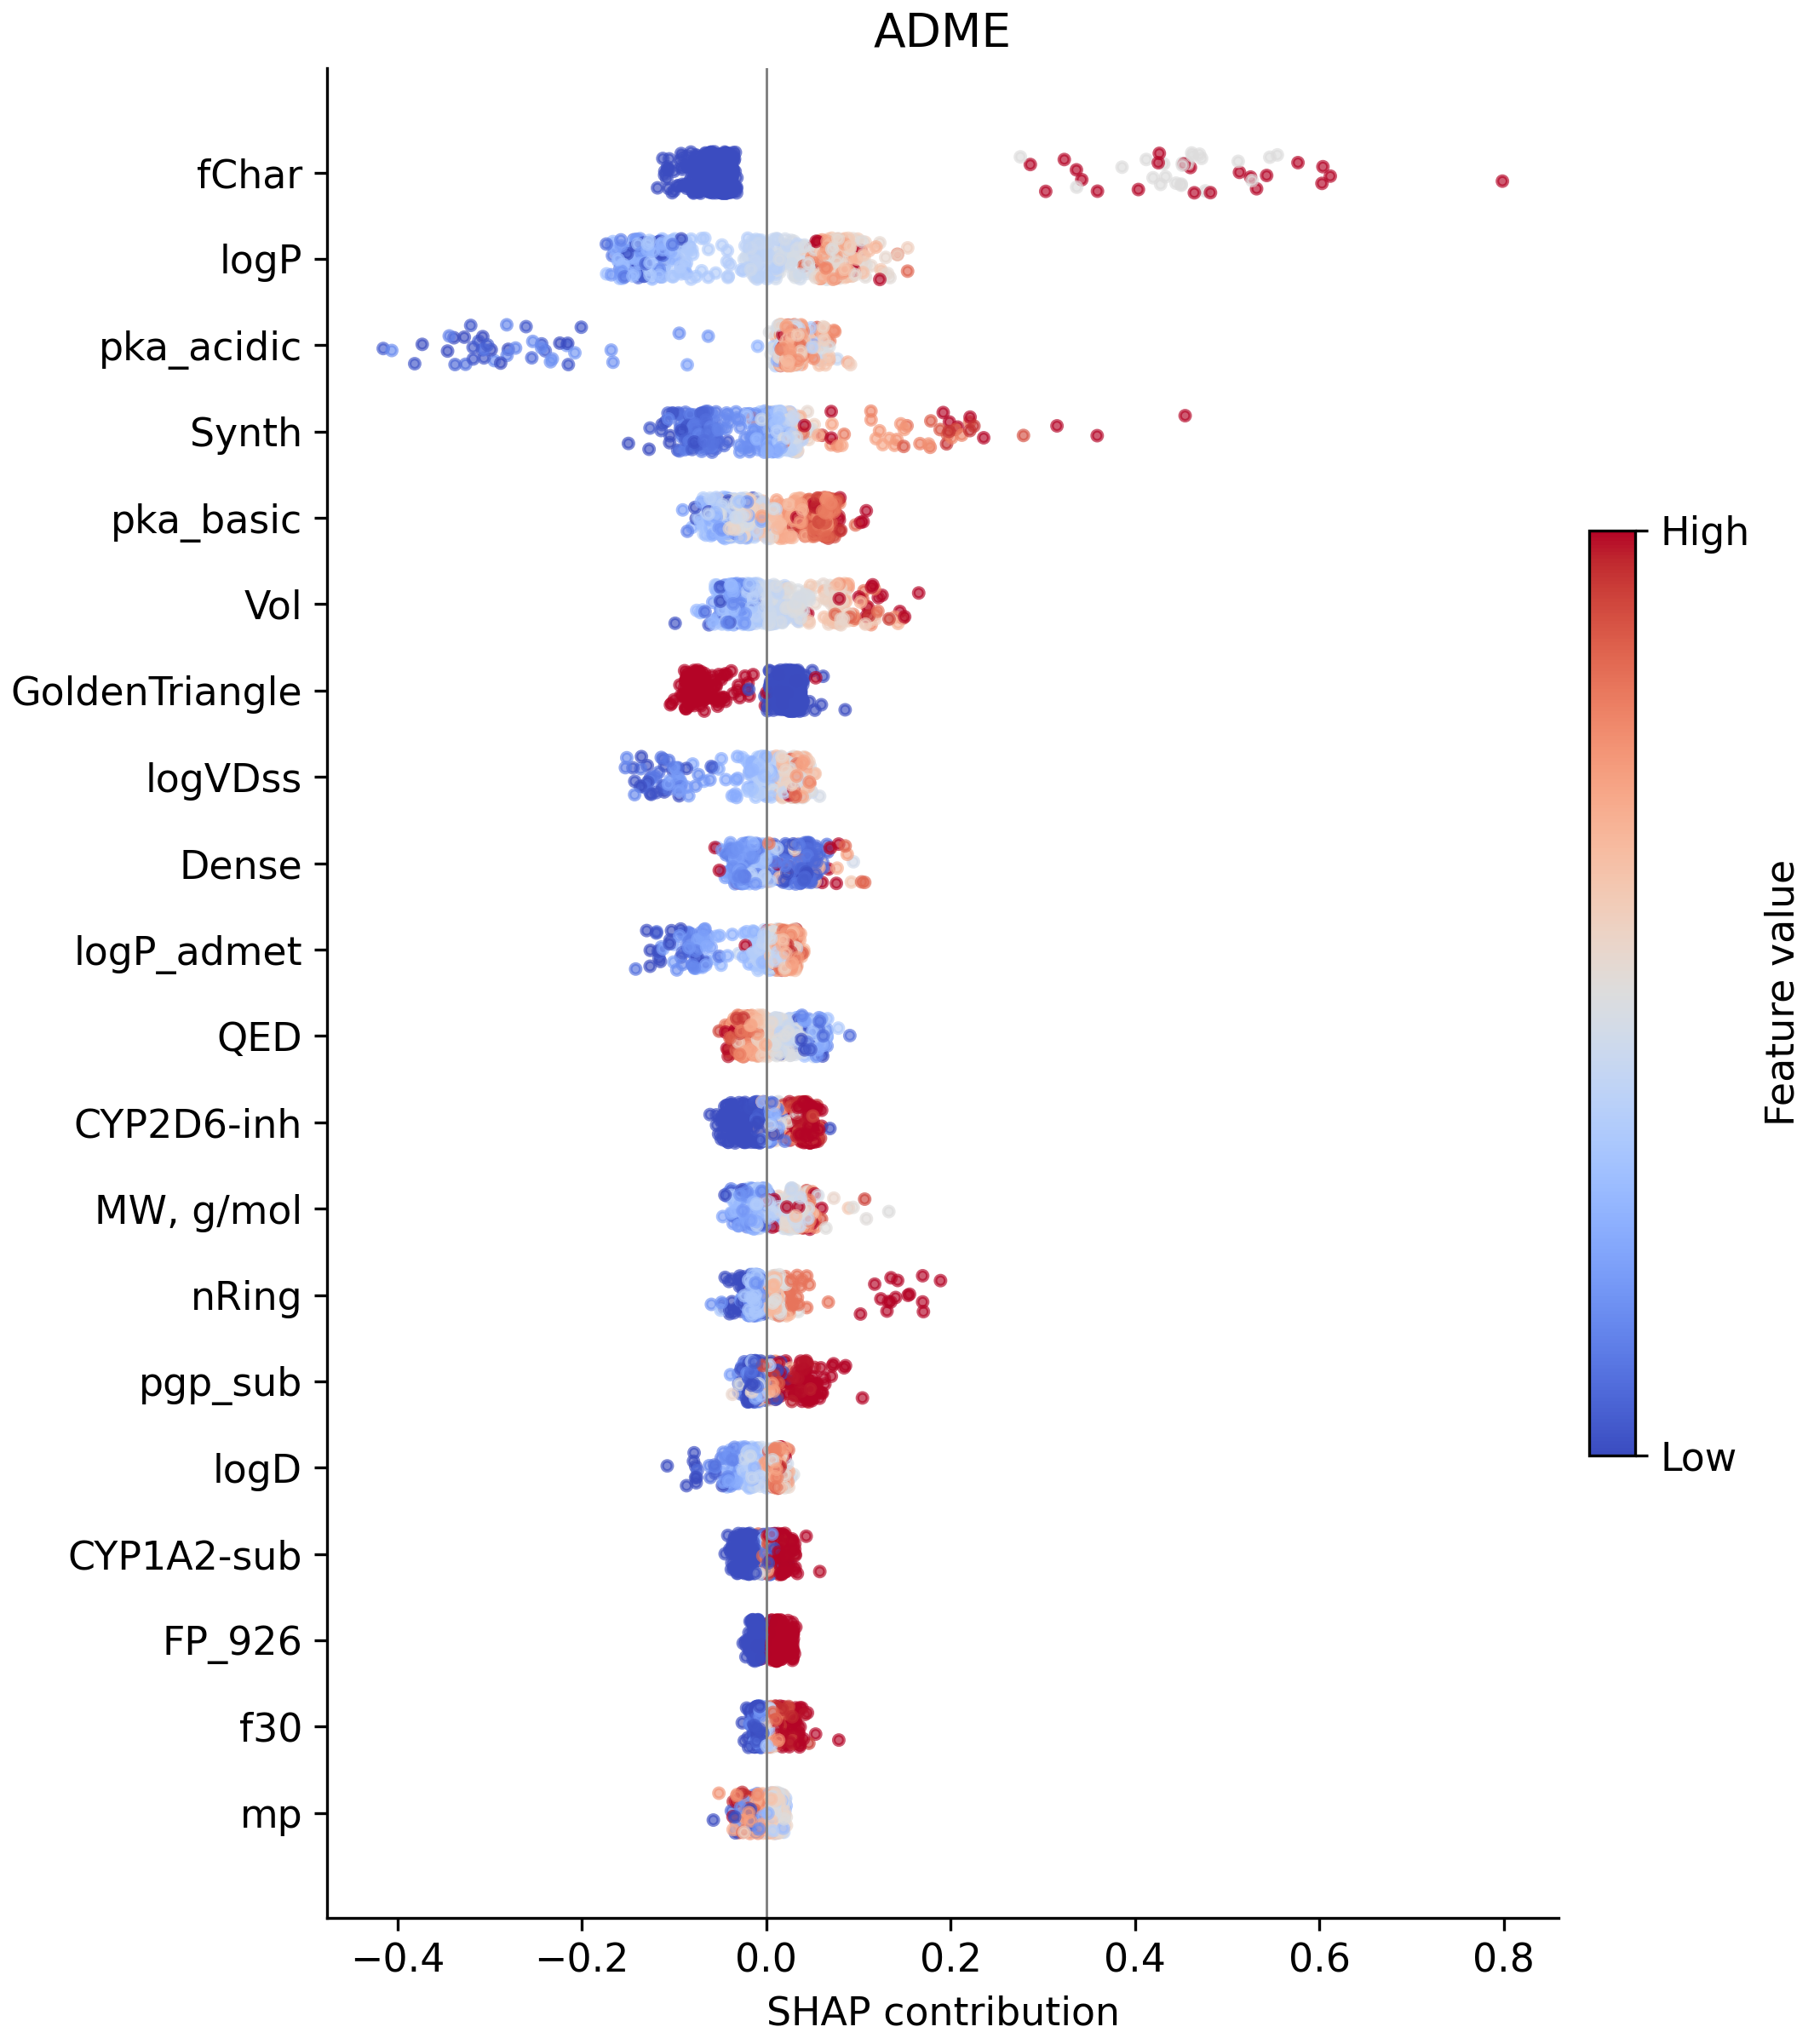

In [5]:
for name in ['Baseline','BBB_pass','ADME']:
    display(Markdown('### '+name))
    figure(f'results/figures/figure4_{name}.png')